In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import chain
from skimage import io
import scipy.stats

##Import any other packages you may need here

EDA is open-ended, and it is up to you to decide how to look at different ways to slice and dice your data. A good starting point is to look at the requirements for the FDA documentation in the final part of this project to guide (some) of the analyses you do. 

This EDA should also help to inform you of how pneumonia looks in the wild. E.g. what other types of diseases it's commonly found with, how often it is found, what ages it affects, etc. 

Note that this NIH dataset was not specifically acquired for pneumonia. So, while this is a representation of 'pneumonia in the wild,' the prevalence of pneumonia may be different if you were to take only chest x-rays that were acquired in an ER setting with suspicion of pneumonia. 

Perform the following EDA:
* The patient demographic data such as gender, age, patient position,etc. (as it is available)
* The x-ray views taken (i.e. view position)
* The number of cases including: 
    * number of pneumonia cases,
    * number of non-pneumonia cases
* The distribution of other diseases that are comorbid with pneumonia
* Number of disease per patient 
* Pixel-level assessments of the imaging data for healthy & disease states of interest (e.g. histograms of intensity values) and compare distributions across diseases.

Note: use full NIH data to perform the first a few EDA items and use `sample_labels.csv` for the pixel-level assassements. 

Also, **describe your findings and how will you set up the model training based on the findings.**

In [2]:
## Below is some helper code to read data for you.
## Load NIH data
all_xray_df = pd.read_csv('/data/Data_Entry_2017.csv')
all_xray_df.sample(3)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
48789,00012364_056.png,Atelectasis|Consolidation|Nodule,56,12364,53,F,AP,2500,2048,0.168,0.168,NaN
4398,00001200_000.png,Atelectasis|Pneumonia,0,1200,22,M,AP,2500,2048,0.171,0.171,NaN
67338,00016623_005.png,Atelectasis|Effusion|Pneumothorax,5,16623,83,M,PA,2990,2991,0.143,0.143,NaN


In [3]:
## Load 'sample_labels.csv' data for pixel level assessments
sample_df = pd.read_csv('sample_labels.csv')
sample_df.sample(3)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
724,00003789_002.png,Infiltration,2,3789,041Y,M,AP,2500,2048,0.171,0.171
753,00003951_000.png,No Finding,0,3951,074Y,F,AP,2500,2048,0.168,0.168
253,00001363_000.png,No Finding,0,1363,020Y,F,PA,2554,2991,0.143,0.143


Inspect the sample data and cleanup if required

In [4]:
all_xray_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
dtypes: float64(3), int64(5), object(4)
memory usage: 10.3+ MB


In [5]:
# drop unamed since no data, probably index column
all_xray_df = all_xray_df.drop('Unnamed: 11', axis=1)
all_xray_df.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
count,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000
mean,8.573751,14346.381743,46.901463,2646.078844,2486.438842,0.155649,0.155649
std,15.406320,8403.876972,16.839923,341.246429,401.268227,0.016174,0.016174
min,0.000000,1.000000,1.000000,1143.000000,966.000000,0.115000,0.115000
25%,0.000000,7310.750000,35.000000,2500.000000,2048.000000,0.143000,0.143000
50%,3.000000,13993.000000,49.000000,2518.000000,2544.000000,0.143000,0.143000
75%,10.000000,20673.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000
max,183.000000,30805.000000,414.000000,3827.000000,4715.000000,0.198800,0.198800


* **Dataset size:** 112,120 rows, no missing values → good quality overall

* **Follow-up #:** Median = 3, Mean = 8.57, Max = 183 → **highly skewed with outliers** (few patients have many visits)

* **Patient ID:** Just an identifier → **not useful for analysis**

* **Patient Age:** Median ≈ 49, Mean ≈ 47 → mostly middle-aged, but **max = 414 is invalid** → needs cleaning

* **Image Width/Height:** Large variation (≈1143–4715) → **images are not uniform** → need resizing for ML, may be with advanced traing not doing here

* **Pixel Spacing (x, y):** Small variation (~0.115–0.198 mm), same for x & y → **consistent square pixels**, but slight differences matter for medical measurements



### Data preperation

* Clean **age outliers**
* Handle **follow-up skew**
* Standardize **image size + spacing** before modeling

In [6]:
all_xray_df['Patient Age'].value_counts(bins=10).sort_index()

(0.586, 42.3]     41465
(42.3, 83.6]      70265
(83.6, 124.9]       374
(124.9, 166.2]       10
(166.2, 207.5]        0
(207.5, 248.8]        0
(248.8, 290.1]        0
(290.1, 331.4]        0
(331.4, 372.7]        0
(372.7, 414.0]        6
Name: Patient Age, dtype: int64

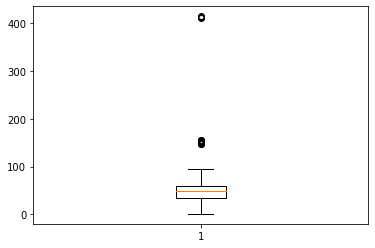

In [7]:
plt.boxplot(all_xray_df['Patient Age']);

In [8]:
# Age above 100 is very few we have target only midle aged so drop records with age above 100 for EDA and later for training
all_xray_df = all_xray_df[all_xray_df['Patient Age'] <= 100]

In [9]:
#As learn from the course apply one hot encoding for disease
all_labels = np.unique(list(chain(*all_xray_df['Finding Labels'].map(lambda x: x.split('|')).tolist())))
all_labels = [x for x in all_labels if len(x)>0]
for c_label in all_labels:
    if len(c_label)>1: # leave out empty labels
        all_xray_df[c_label] = all_xray_df['Finding Labels'].map(lambda finding: 1.0 if c_label in finding else 0)
        sample_df[c_label] = sample_df['Finding Labels'].map(lambda finding: 1.0 if c_label in finding else 0)
all_xray_df.sample(3)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
111309,00030408_013.png,Atelectasis|Effusion|Infiltration,13,30408,67,M,AP,3056,2544,0.139,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
43276,00011164_000.png,Nodule,0,11164,10,F,PA,2992,2991,0.143,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4988,00001334_000.png,No Finding,0,1334,44,F,PA,2838,2629,0.143,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### EDA: The patient demographic data such as gender, age, patient position,etc. (as it is available)
### 1. Gender Distribution

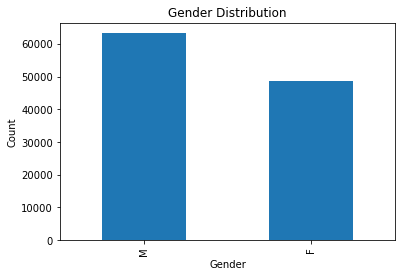

In [10]:
all_xray_df['Patient Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

As per above histogram

* **Male Dominance:** The dataset is skewed toward male patients, who make up roughly **56%** of the total.
* **The Gap:** There are approximately **14k more** male records than female records.
* **Sample Size:** Despite imbalance, both groups have a **massive sample size** , which is excellent .
* **Bias Check:** Since there is a visible imbalance, we may want to ensure the model performs equally well on both genders rather than favoring the majority (males).
### 2. Age Analysis

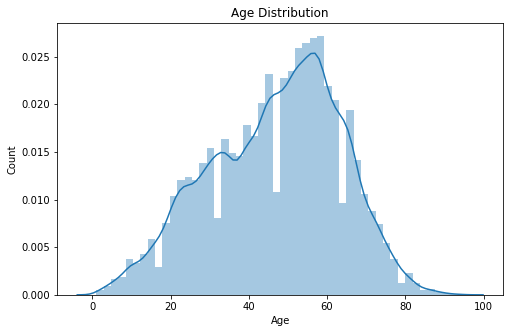

In [11]:
plt.figure(figsize=(8,5))
sns.distplot(all_xray_df['Patient Age'], hist=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Here is what that plot reveals:

* **Peak Demographic:** Most patients are between **45 and 65**, with a clear peak around **58 years old**.
* **Main Range:** The bulk of the data lives between **20 and 75**. 
* **Missing Groups:** There is very little data for **pediatrics (<15)** or the **very elderly (>85)**.
* **Hidden Trend:** There’s a small secondary "bump" around **age 30–35**, suggesting a smaller group of younger patients.
* **The Y-Axis:** Note the decimals—it’s showing **density** (proportions), not the raw number of patients.
* **Data "Jagginess":** The spikey bars suggest either rounding in the records (e.g., people reporting age 50 instead of 49) or specific binning settings in the code.

**In short:** dataset is dominated by middle-aged to older adults.

### 3. View Position

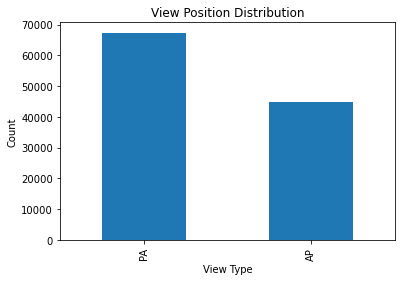

In [12]:
all_xray_df['View Position'].value_counts().plot(kind='bar')
plt.title("View Position Distribution")
plt.xlabel("View Type")
plt.ylabel("Count")
plt.show()

### Insights from View Position

* **PA is Majority:** Posteroanterior (PA) views make up roughly **60%** (~67k) of the dataset.
* **AP is Significant:** Anteroposterior (AP) views make up the remaining **40%** (~45k).
* **Clinical Context:** PA is the "standard" view for patients who can stand. AP views are typically "portable" X-rays taken for patients who are bedbound or too ill to stand.
* **Imaging Difference:** In AP views, the heart often appears larger due to magnification. Your model must be robust enough to distinguish actual pathology from these positional differences.

### 4. Follow-up Analysis

In [13]:
all_xray_df['Follow-up #'].describe()

count    112104.000000
mean          8.574172
std          15.406734
min           0.000000
25%           0.000000
50%           3.000000
75%          10.000000
max         183.000000
Name: Follow-up #, dtype: float64

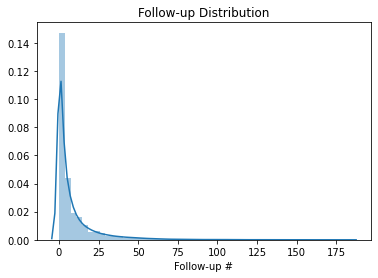

In [14]:
sns.distplot(all_xray_df['Follow-up #'], hist=True)
plt.title("Follow-up Distribution")
plt.show()

Plot shows a classic **long-tail distribution** (right-skewed).for the given data it means:

* **Majority are "One-Offs":** The median is only **3**, and 25% of patients have **0** follow-ups. Most people in this dataset had an X-ray once or twice and didn't return.
* **The "Average" is Misleading:** The mean (**8.5**) is much higher than the median (**3**) because it's being pulled up by extreme outliers. 
* **Frequent Flyers:** There are extreme outliers—someone has **183 follow-ups**. These likely represent chronic patients or long-term hospitalizations.
* **High Variability:** The standard deviation (**15.4**) is nearly double the mean, confirming that the "typical" experience varies wildly across the patient base.


**Bottom line:** model will mostly see "new" cases, but it needs to be aware that a small subset of patients accounts for a disproportionately large number of images.

### 5. Patient vs Image

In [15]:
num_patients = all_xray_df['Patient ID'].nunique()
num_images = len(all_xray_df)

print("Total Patients:", num_patients)
print("Total Images:", num_images)

Total Patients: 30802
Total Images: 112104


Based on these totals, here is the short derivation:

* **Average Images per Patient:** Approximately **3.64 images** per person ($112,104 \div 30,802$).
* **Dataset Scale:** With over 100k images, this is a **large-scale dataset**, providing enough volume and variety for training robust Deep Learning or Computer Vision models.
* **Data Density:** Having multiple images per patient is valuable for longitudinal studies (tracking how a disease progresses or heals over time).

### 7. Combined Demographic Insight

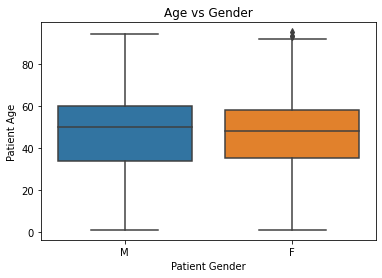

In [16]:
sns.boxplot(x='Patient Gender', y='Patient Age', data=all_xray_df)
plt.title("Age vs Gender")
plt.show()

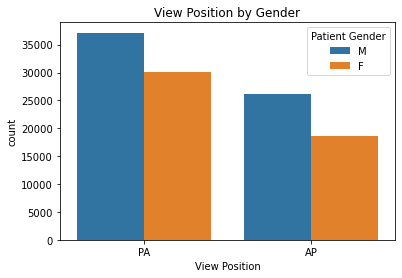

In [17]:
sns.countplot(x='View Position', hue='Patient Gender', data=all_xray_df)
plt.title("View Position by Gender")
plt.show()

### Age vs. Gender (Box Plot)
* **Identical Distributions:** The medians (middle lines) and Interquartile Ranges (the boxes) are almost identical. 
* **Median Age:** Both genders have a median age of roughly **48–50**.
* **Outliers:** There are some elderly outliers (dots at the top) in the female group reaching age **90+**, while the male group caps out slightly lower.
* **Insight:** Age does not vary significantly by gender in this dataset; both groups follow the same demographic pattern.

---

### View Position by Gender (Bar Chart)
* **Consistent Imbalance:** Males (blue) outnumber females (orange) in **both** PA and AP views.
* **Preference:** Both genders are more likely to have a **PA view** (standard) than an AP view (portable/emergency).
* **Ratio:** The ratio of PA to AP appears consistent across both genders; there isn't a specific gender that is disproportionately more likely to be in the "emergency" AP category.
* **Insight:** data imbalance (more males) is "baked into" every imaging category, not just one.
---

###  EDA: The number of cases including: 
    * number of diseased,
    * number of non-diseased cases

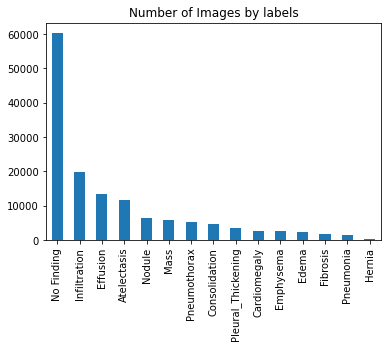

In [18]:
ax = all_xray_df[all_labels].sum().sort_values(ascending=False).plot(kind='bar');
ax.set(title = 'Number of Images by labels');

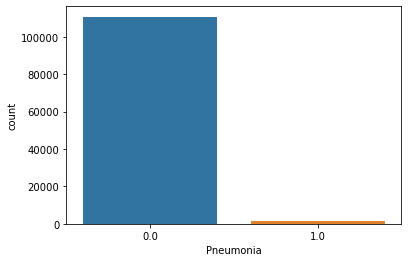

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pneumonia', data=all_xray_df)


In [20]:
total_cases = len(all_xray_df)
pneumonia_cases = all_xray_df['Pneumonia'].sum()
non_pneumonia_cases = total_cases - pneumonia_cases
no_findings = all_xray_df['No Finding'].sum()

print(f"Total Cases: {total_cases}")
print(f"No Findings Cases: {no_findings}")
print(f"Pneumonia Cases: {pneumonia_cases}")
print(f"Non-Pneumonia Cases: {non_pneumonia_cases}")

print(f"Pneumonia Percentage: {(pneumonia_cases/total_cases)*100:.2f}%")
print(f"Non-Pneumonia Percentage: {(non_pneumonia_cases/total_cases)*100:.2f}%")
print(f"No Findings Percentage: {(no_findings/total_cases)*100:.2f}%")
print(f"Findings Percentage: {(1 - no_findings/total_cases)*100:.2f}%")

Total Cases: 112104
No Findings Cases: 60353.0
Pneumonia Cases: 1430.0
Non-Pneumonia Cases: 110674.0
Pneumonia Percentage: 1.28%
Non-Pneumonia Percentage: 98.72%
No Findings Percentage: 53.84%
Findings Percentage: 46.16%


In [21]:
no_finding_df = all_xray_df[all_xray_df['No Finding'] == 1]

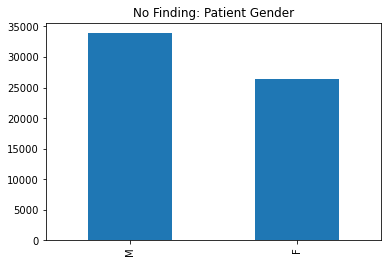

In [22]:
no_finding_df['Patient Gender'].value_counts().plot(kind="bar");
plt.title('No Finding: Patient Gender');

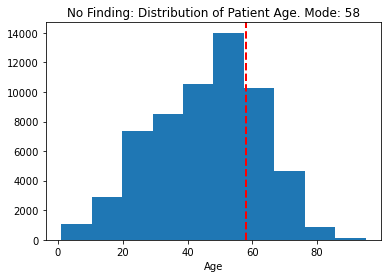

In [23]:
plt.hist(no_finding_df['Patient Age']);

mode_val_nf = no_finding_df['Patient Age'].mode()[0]
plt.title('No Finding: Distribution of Patient Age. Mode: {}'.format(mode_val_nf));
plt.xlabel('Age');
plt.axvline(mode_val_nf, color='r', linestyle='dashed', linewidth=2);

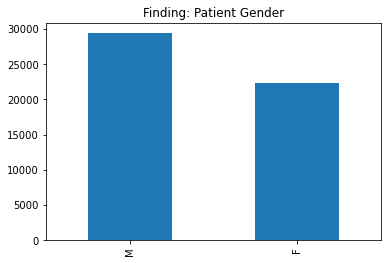

In [24]:
finding_df = all_xray_df[all_xray_df['No Finding'] == 0]
finding_df['Patient Gender'].value_counts().plot(kind="bar");
plt.title('Finding: Patient Gender');

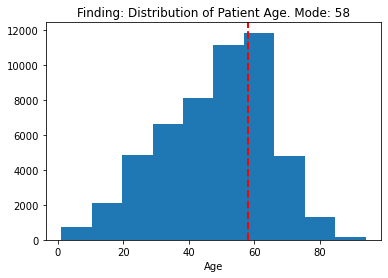

In [25]:
plt.hist(finding_df['Patient Age']);

mode_val = finding_df['Patient Age'].mode()[0]
plt.title('Finding: Distribution of Patient Age. Mode: {}'.format(mode_val));
plt.xlabel('Age');
plt.axvline(mode_val, color='r', linestyle='dashed', linewidth=2);

### EDA: The distribution of other diseases that are comorbid with pneumonia

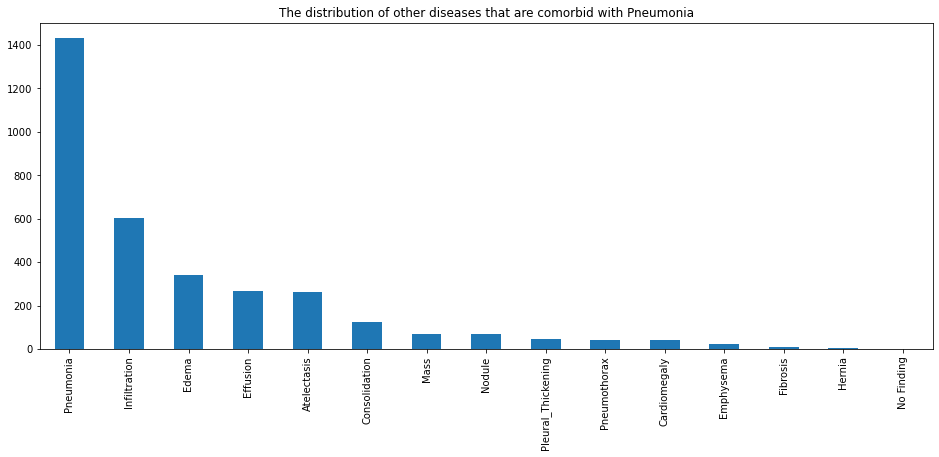

In [26]:
plt.figure(figsize=(16,6))
all_xray_df[all_xray_df.Pneumonia==1][all_labels].sum().sort_values(ascending=False).plot(kind='bar');
plt.title('The distribution of other diseases that are comorbid with Pneumonia');

In [27]:
all_xray_df[all_xray_df.Pneumonia==1][all_labels].sum()

Atelectasis            262.0
Cardiomegaly            41.0
Consolidation          123.0
Edema                  340.0
Effusion               268.0
Emphysema               23.0
Fibrosis                11.0
Hernia                   3.0
Infiltration           605.0
Mass                    71.0
No Finding               0.0
Nodule                  70.0
Pleural_Thickening      48.0
Pneumonia             1430.0
Pneumothorax            41.0
dtype: float64

---
Pneumonia cases frequently co-occur with other thoracic diseases such as infiltration, effusion, and atelectasis. This confirms that pneumonia is often not an isolated finding but part of a broader pathological presentation. Such overlap increases diagnostic complexity and makes pneumonia detection a challenging multi-label classification problem.

### EDA: Number of disease per patient 

In [28]:
all_xray_df['disease_count'] = all_xray_df[all_labels].sum(axis=1)
all_xray_df['disease_count'].describe()

count    112104.000000
mean          1.262372
std           0.629874
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           9.000000
Name: disease_count, dtype: float64

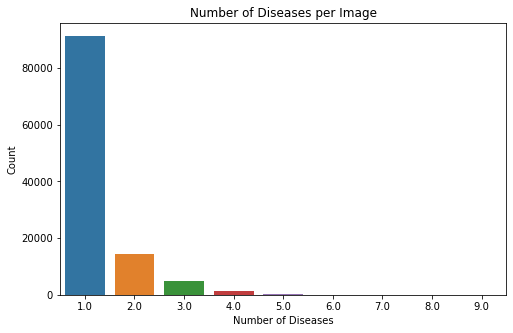

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(x='disease_count', data=all_xray_df)

plt.title("Number of Diseases per Image")
plt.xlabel("Number of Diseases")
plt.ylabel("Count")
plt.show()

In [30]:
disease_count_dist = all_xray_df['disease_count'].value_counts().sort_index()

disease_percentage = (
    disease_count_dist / len(all_xray_df)
) * 100

print(pd.DataFrame({
    'count': disease_count_dist,
    'percentage': disease_percentage
}))

     count  percentage
1.0  91312   81.452937
2.0  14302   12.757796
3.0   4856    4.331692
4.0   1247    1.112360
5.0    301    0.268501
6.0     67    0.059766
7.0     16    0.014272
8.0      1    0.000892
9.0      2    0.001784


In [31]:
patient_disease_count = all_xray_df.groupby(
    'Patient ID'
)['disease_count'].mean()

print(patient_disease_count.describe())

count    30802.000000
mean         1.132991
std          0.351412
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: disease_count, dtype: float64


---
This dataset is characterized by extreme **label sparsity** and a heavy **single-diagnosis bias**:

* **Primary Composition:** Over **81%** of patients have only one disease. Combined with dual-diagnoses, **94%** of data is covered, making the "average" patient clinically straightforward.
* **Exponential Decay:** There is a massive drop-off in frequency as disease counts increase; patients with $\ge 4$ conditions make up only **1.45%** of the total.
* **The Long Tail:** The counts of 8 and 9 are extreme outliers (only 3 patients total). These are statistically insignificant for training but highlight rare clinical complexity.
* **Modeling Takeaway:** the resaulting model will be excellent at identifying single pathologies but will likely struggle with multi-label "comorbidity" predictions due to the lack of complex training examples.
---
### EDA: Pixel-level assessments of the imaging data for healthy & disease states of interest (e.g. histograms of intensity values) and compare distributions across diseases.

In [32]:
# image paths to to sample dataframe
all_image_paths = {os.path.basename(x): x for x in 
                   glob(os.path.join('/data','images*', '*', '*.png'))}
print('Scans found:', len(all_image_paths), ', Total Headers', sample_df.shape[0])
sample_df['path'] = sample_df['Image Index'].map(all_image_paths.get)
sample_df.sample(3)

Scans found: 112120 , Total Headers 5606


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,...,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,path
154,00000877_023.png,No Finding,23,877,039Y,M,AP,2500,2048,0.168,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,/data/images_001/images/00000877_023.png
1821,00009600_009.png,Cardiomegaly|Effusion|Infiltration,9,9600,065Y,F,AP,2500,2048,0.168,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,/data/images_005/images/00009600_009.png
762,00004006_026.png,Atelectasis,26,4006,034Y,F,AP,2500,2048,0.168,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,/data/images_003/images/00004006_026.png


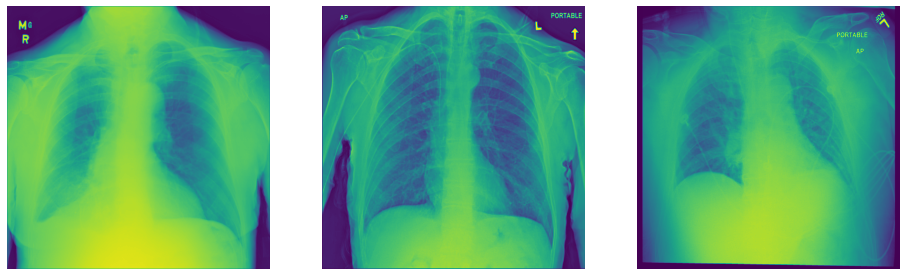

In [33]:
plt.figure(figsize=(16,6))
healthy_df = sample_df[
    sample_df['No Finding'] == 1
]
for cnt in range(3):
    ax=plt.subplot(1, 3, cnt+1)
    ax.imshow(io.imread(healthy_df['path'].iloc[cnt]));
    ax.set_axis_off()

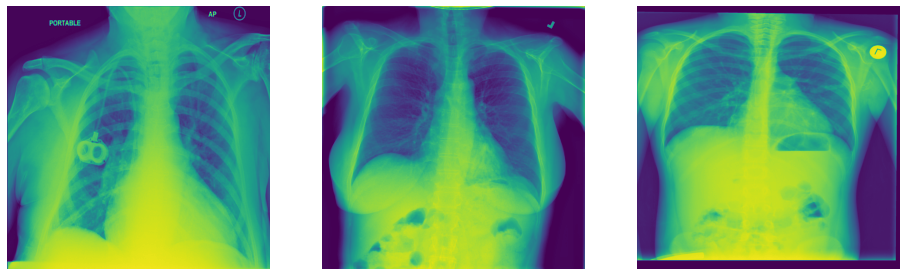

In [34]:
plt.figure(figsize=(16,6))
pneumonia_df = sample_df[
    sample_df['Pneumonia'] == 1
]
for cnt in range(3):
    ax=plt.subplot(1, 3, cnt+1)
    ax.imshow(io.imread(pneumonia_df['path'].iloc[cnt]));
    ax.set_axis_off()

#### Inspect intensities of healthy patient & patient with pneumonia to find a threshold for removing background

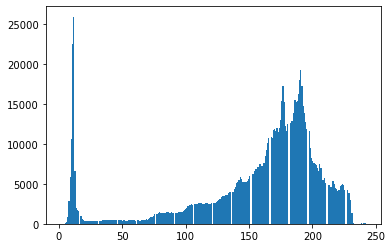

In [35]:
img_healthy = io.imread(healthy_df['path'].iloc[0])
x = plt.hist(img_healthy.ravel(),bins=256)

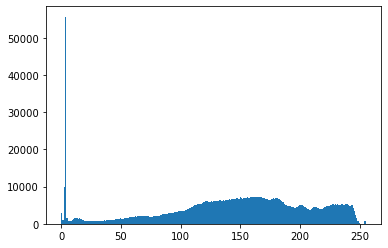

In [36]:
img_pneunomia = io.imread(pneumonia_df['path'].iloc[0])
x = plt.hist(img_pneunomia.ravel(),bins=256)

In [37]:
thresh = 20

img_healthy_bin = (img_healthy > thresh) * 255
img_pneunomia_bin = (img_pneunomia > thresh) * 255

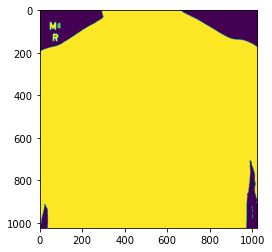

In [38]:
plt.imshow(img_healthy_bin);

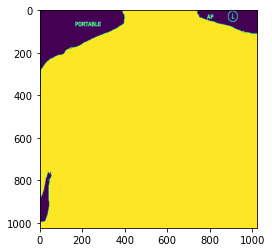

In [39]:
plt.imshow(img_pneunomia_bin);

In [40]:
def plot_intensities_hist(df):
    '''
    plot histogram of intensities x-ray images
    processing 25 images are fare to arrive a peak conclusion for this project
    '''
    intensities = []
    for path in df['path'][:25]: 

        img = io.imread(path)
        img_mask = (img > thresh) & (img < 250)
        intensities.extend(img[img_mask].tolist())
        
    plt.hist(intensities, bins=256);
    
    mode_val = scipy.stats.mode(intensities)[0][0]
    plt.title('Mode of intensities: {}'.format(mode_val))
    plt.axvline(mode_val, color='r', linestyle='dashed', linewidth=2)

In [41]:
def plot_intensities_hist_cell(ax, df, disease_name):
    """
    Plot histogram of image intensities for a given disease
    using first 25 images.
    """

    intensities = []

    for path in df['path'][:25]:
        img = io.imread(path)

        # mask low-value noise + overly bright values
        img_mask = (img > thresh) & (img < 250)

        intensities.extend(img[img_mask].tolist())

    ax.hist(intensities, bins=256)

    mode_val = scipy.stats.mode(intensities)[0][0]

    ax.set_title(f"{disease_name}\nMode: {mode_val}")
    ax.axvline(mode_val, color='r', linestyle='dashed', linewidth=2)

### Healthy Patients

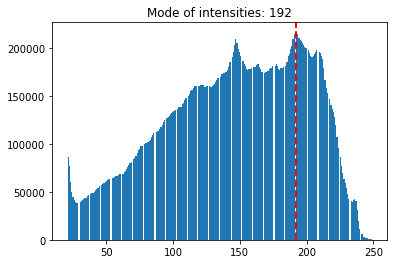

In [42]:
plot_intensities_hist(healthy_df);

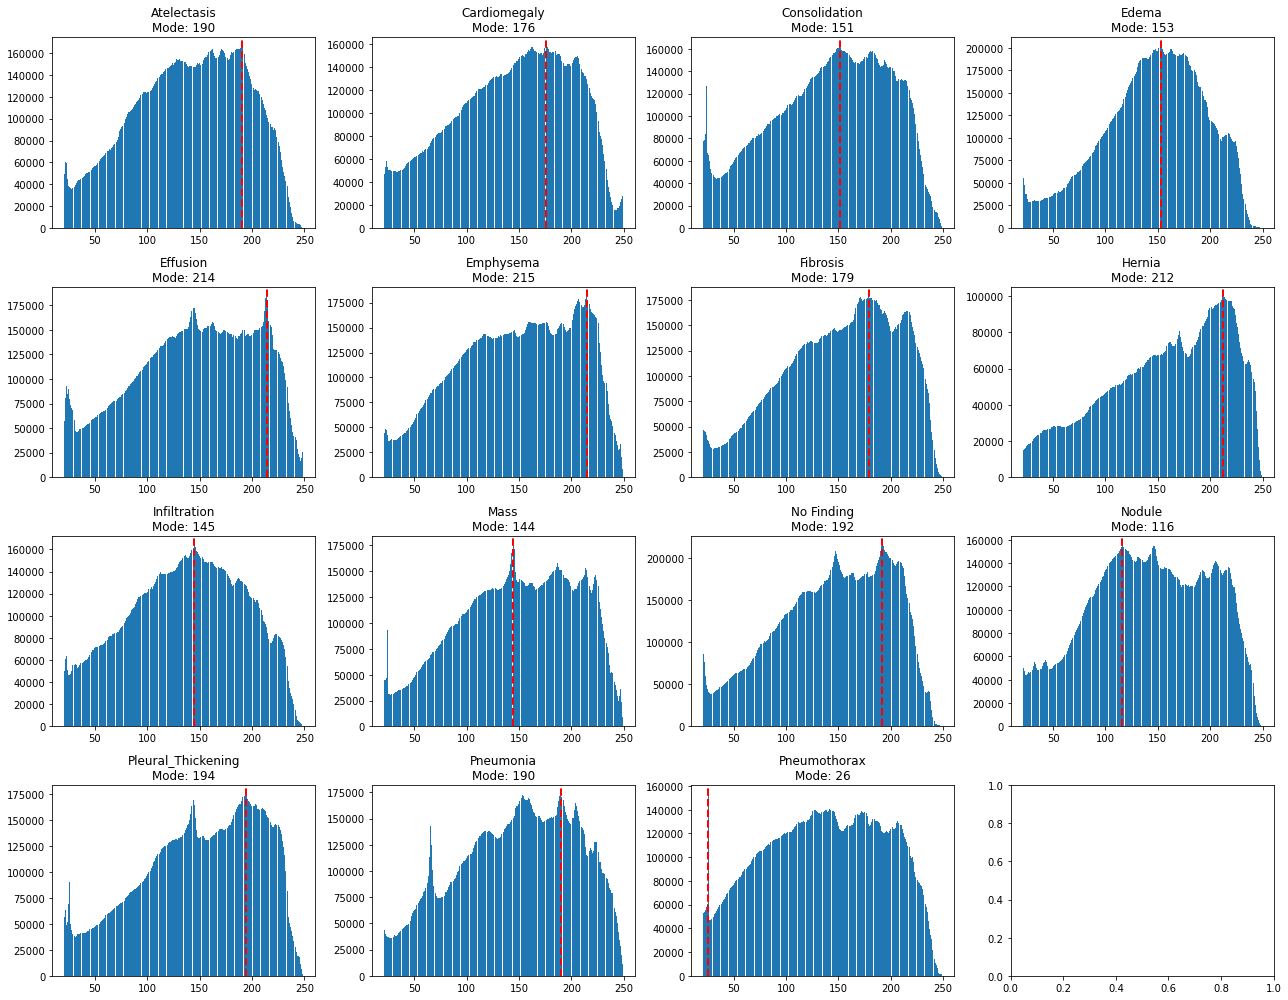

In [43]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(18, 14)
)

axes = axes.flatten()

for i, disease in enumerate(all_labels):

    disease_df = sample_df[
        sample_df[disease] == 1
    ]

    plot_intensities_hist_cell(
        axes[i],
        disease_df,
        disease
    )

plt.tight_layout()
plt.show()

---
### EDA: Summary for intensities

Comparing healthy vs. diseased pixel intensities reveals three distinct patterns:

* **The Baseline:** Healthy patients have a **Mode of 192**, showing a bright-leaning, balanced distribution typical of clear bone and well-aerated tissue.
* **Physical Deviations:** * **Air Presence:** **Pneumothorax** is a massive outlier with a **Mode of 26** (nearly black), reflecting trapped air.
    * **Fluid/Density:** **Effusion (214)** and **Hernia (212)** peak higher than healthy, indicating radio-opaque "white" areas.
    * **Tissue Changes:** **Mass (144)** and **Nodule (116)** shift the peak toward mid-grays, as growths replace dark air with denser tissue.
* **The Diagnostic Limit:** Most diseases (Atelectasis, Infiltration, Pneumonia) have modes very close to "Healthy." 

**Final Verdict:** While extreme air or fluid shifts the histogram significantly, raw intensity is too similar across most categories for reliable diagnosis. Probably for advanced study model prioritize **spatial patterns and textures** over simple brightness.